In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Supuestos de negocio (únicos valores que no salen de los datos) ──────
COSTE_CONTACTO = 0.50      # € por cliente contactado: email + gestión de campaña
COSTE_FIJO     = 10000     # € de diseño, creatividad y horas de equipo
N_SIMULACIONES = 10000     # tiradas Monte Carlo
SEMILLA        = 42

rng = np.random.default_rng(SEMILLA)

In [5]:
ruta_raw  = "../data/raw/"
ruta_proc = "../data/processed/"

df_sal = pd.read_csv(ruta_raw + "sales.csv", index_col=0)
df_prd = pd.read_csv(ruta_raw + "product_description.csv", index_col=0)

scoring_pp = pd.read_csv(ruta_proc + "scoring_pension_plan.csv")
scoring_em = pd.read_csv(ruta_proc + "scoring_em_acount.csv")
grupos     = pd.read_csv(ruta_proc + "clientes_grupos.csv")
grupos_abril = pd.read_csv(ruta_proc + "clientes_grupos_abril.csv")

print("Ventas:", df_sal.shape)
print("Scoring pension_plan:", scoring_pp.shape)
print("Scoring em_acount:", scoring_em.shape)
print("Grupos:", grupos.shape)

Ventas: (240773, 5)
Scoring pension_plan: (425556, 2)
Scoring em_acount: (146575, 2)
Grupos: (442995, 3)


In [6]:
# ¿Qué producto es cada product_ID y cuánto margen deja cada venta?
margen_prod = (df_sal.merge(df_prd, left_on="product_ID", right_on="pk_product_ID", how="left")
               .groupby(["product_ID", "product_desc"])
               .agg(ventas=("pk_sale", "count"),
                    margen_medio=("net_margin", "mean"),
                    margen_mediano=("net_margin", "median"),
                    margen_std=("net_margin", "std"),
                    margen_total=("net_margin", "sum"))
               .round(1)
               .sort_values("margen_total", ascending=False))

margen_prod["pct_margen_total"] = (margen_prod["margen_total"] / margen_prod["margen_total"].sum() * 100).round(1)
print(margen_prod)

                               ventas  margen_medio  margen_mediano  \
product_ID product_desc                                               
1364       pension_plan         19369        5976.4          5641.1   
4657       em_acount           117435          70.0            70.0   
2335       short_term_deposit    4441        1486.4          1414.0   
2336       long_term_deposit     4227        1496.9          1431.8   
3819       debit_card           38840          60.0            60.0   
2673       securities            1157        1497.8          1435.7   
1119       funds                  880        1499.0          1432.4   
2234       payroll              18750          69.9            69.9   
2235       payroll_account      18110          70.0            69.9   
8871       emc_account          12323          70.0            70.0   
2312       credit_card           5206          60.0            60.0   
9001       loans                   25        2183.9          2198.1   
4033  

In [7]:
# Productos de la campaña: fijamos margen medio (para el cálculo de ingresos)
# y la lista de márgenes reales de cada venta (para muestrear en la simulación Monte Carlo)
PRODUCTOS = {
    "pension_plan": {"id": 1364, "scoring": scoring_pp, "col_prob": "probabilidad_pension_plan"},
    "em_acount":    {"id": 4657, "scoring": scoring_em, "col_prob": "probabilidad_em_acount"},
}

for nombre, p in PRODUCTOS.items():
    margenes = df_sal.loc[df_sal["product_ID"] == p["id"], "net_margin"].values
    p["margen_medio"] = margenes.mean()
    p["margenes"]     = margenes
    print(f"{nombre:13s} | margen medio {p['margen_medio']:8.1f} € | {len(margenes):,} ventas reales para muestrear")

pension_plan  | margen medio   5976.4 € | 19,369 ventas reales para muestrear
em_acount     | margen medio     70.0 € | 117,435 ventas reales para muestrear


In [8]:
# Curva de conversión sobre el mes de validación (probabilidad predicha vs compra real).
# Para cada corte acumulado (top 1%, 2%, ... 100%) mide qué % de los contactados compró de verdad.
# Esta conversión real es el dato que convierte contactos en ventas en el cálculo económico.
def curva_conversion(df_val, cortes=(1, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50, 75, 100)):
    """
    Conversión real acumulada si contactamos al top X% de clientes por probabilidad.
    Devuelve una fila por corte con: clientes contactados, compras, conversión y lift.
    """
    df = df_val.sort_values("probabilidad", ascending=False).reset_index(drop=True)
    tasa_base = df["compra_real"].mean()
    filas = []
    for pct in cortes:
        n = int(len(df) * pct / 100)
        top = df.iloc[:n]
        compras = int(top["compra_real"].sum())
        conv = compras / n
        filas.append({
            "top_pct": pct,
            "clientes": n,
            "compras": compras,
            "conversion_pct": round(conv * 100, 2),
            "lift": round(conv / tasa_base, 1),
            "pct_compras_capturadas": round(compras / df["compra_real"].sum() * 100, 1),
        })
    return pd.DataFrame(filas), tasa_base

for nombre, p in PRODUCTOS.items():
    val = pd.read_csv(ruta_proc + f"validacion_{nombre}.csv")
    p["validacion"] = val
    p["curva"], p["tasa_base"] = curva_conversion(val)
    print(f"\n{'='*60}\n{nombre}  |  tasa base {p['tasa_base']*100:.2f}%  |  {len(val):,} clientes en validación")
    print(p["curva"].to_string(index=False))


pension_plan  |  tasa base 0.66%  |  422,161 clientes en validación
 top_pct  clientes  compras  conversion_pct  lift  pct_compras_capturadas
       1      4221      295            6.99  10.6                    10.6
       2      8443      515            6.10   9.2                    18.5
       3     12664      727            5.74   8.7                    26.0
       5     21108     1075            5.09   7.7                    38.5
       7     29551     1348            4.56   6.9                    48.3
      10     42216     1660            3.93   5.9                    59.5
      15     63324     2026            3.20   4.8                    72.6
      20     84432     2251            2.67   4.0                    80.7
      30    126648     2572            2.03   3.1                    92.2
      40    168864     2674            1.58   2.4                    95.8
      50    211080     2710            1.28   1.9                    97.1
      75    316620     2771            0.88

In [9]:
def tabla_beneficio(p, coste_contacto=COSTE_CONTACTO, coste_fijo=COSTE_FIJO):
    """
    Aplica la curva de conversión de validación a la población elegible de hoy
    y calcula el resultado económico de contactar al top X%.
    """
    n_elegibles = len(p["scoring"])
    t = p["curva"][["top_pct", "conversion_pct", "lift"]].copy()
    t["clientes"]   = (n_elegibles * t["top_pct"] / 100).astype(int)
    t["ventas"]     = (t["clientes"] * t["conversion_pct"] / 100).round(0).astype(int)
    t["ingreso"]    = (t["ventas"] * p["margen_medio"]).round(0)
    t["coste"]      = (t["clientes"] * coste_contacto + coste_fijo).round(0)
    t["beneficio"]  = t["ingreso"] - t["coste"]
    t["roi"]        = (t["beneficio"] / t["coste"]).round(1)
    # Marginal: qué aporta el tramo añadido respecto al corte anterior
    t["ventas_marg"]    = t["ventas"].diff().fillna(t["ventas"]).astype(int)
    t["clientes_marg"]  = t["clientes"].diff().fillna(t["clientes"]).astype(int)
    t["conv_marg_pct"]  = (t["ventas_marg"] / t["clientes_marg"] * 100).round(2)
    t["breakeven_coste"] = (t["conv_marg_pct"] / 100 * p["margen_medio"]).round(2)
    return t

for nombre, p in PRODUCTOS.items():
    p["beneficio"] = tabla_beneficio(p)
    print(f"\n{'='*70}\n{nombre}  |  {len(p['scoring']):,} elegibles  |  margen {p['margen_medio']:.0f} €  |  coste contacto {COSTE_CONTACTO} €")
    print(p["beneficio"].to_string(index=False))


pension_plan  |  425,556 elegibles  |  margen 5976 €  |  coste contacto 0.5 €
 top_pct  conversion_pct  lift  clientes  ventas    ingreso    coste  beneficio   roi  ventas_marg  clientes_marg  conv_marg_pct  breakeven_coste
       1            6.99  10.6      4255     297  1775001.0  12128.0  1762873.0 145.4          297           4255           6.98           417.16
       2            6.10   9.2      8511     519  3101770.0  14256.0  3087514.0 216.6          222           4256           5.22           311.97
       3            5.74   8.7     12766     733  4380728.0  16383.0  4364345.0 266.4          214           4255           5.03           300.61
       5            5.09   7.7     21277    1083  6472480.0  20638.0  6451842.0 312.6          350           8511           4.11           245.63
       7            4.56   6.9     29788    1358  8116000.0  24894.0  8091106.0 325.0          275           8511           3.23           193.04
      10            3.93   5.9     42555    1

In [10]:
# Cruce segmentación × propensión, sin fuga temporal:
#  a) validación (compras de mayo) × grupo de ABRIL  → qué grupos compran de verdad
#  b) scoring (lista para junio)   × grupo de MAYO   → a quién estaríamos contactando
def cruce_grupos(p, corte_pct):
    val = p["validacion"].merge(grupos_abril, on="pk_cid", how="left")
    val["nombre_grupo"] = val["nombre_grupo"].fillna("Sin grupo")
    umbral = val["probabilidad"].quantile(1 - corte_pct / 100)
    val["en_top"] = val["probabilidad"] >= umbral
    por_grupo = (val.groupby("nombre_grupo")
                 .agg(clientes=("pk_cid", "count"),
                      compras=("compra_real", "sum"),
                      conversion_pct=("compra_real", lambda s: round(s.mean() * 100, 2)),
                      pct_en_top=("en_top", lambda s: round(s.mean() * 100, 1)))
                 .sort_values("conversion_pct", ascending=False))
    por_grupo["pct_de_las_compras"] = (por_grupo["compras"] / por_grupo["compras"].sum() * 100).round(1)

    sc = p["scoring"].merge(grupos, on="pk_cid", how="left")
    sc["nombre_grupo"] = sc["nombre_grupo"].fillna("Sin grupo")
    n_top = int(len(sc) * corte_pct / 100)
    top = sc.nlargest(n_top, p["col_prob"])
    composicion = top["nombre_grupo"].value_counts().rename("clientes_en_top").to_frame()
    composicion["pct_del_top"] = (composicion["clientes_en_top"] / n_top * 100).round(1)
    return por_grupo, composicion

for nombre, corte in [("pension_plan", 30), ("em_acount", 30)]:
    por_grupo, composicion = cruce_grupos(PRODUCTOS[nombre], corte)
    print(f"\n{'='*70}\n{nombre} — conversión por grupo (grupo de abril, compra de mayo)")
    print(por_grupo.to_string())
    print(f"\n{nombre} — composición del top {corte}% del scoring (grupo de mayo)")
    print(composicion.to_string())


pension_plan — conversión por grupo (grupo de abril, compra de mayo)
                                clientes  compras  conversion_pct  pct_en_top  pct_de_las_compras
nombre_grupo                                                                                     
Clientes de nómina                  9899     1484           14.99        92.4                53.2
Particulares con tarjeta           18633      332            1.78        99.6                11.9
Particulares básicos               62095      356            0.57        74.7                12.8
Universitarios recién llegados     68375      306            0.45        24.1                11.0
TOP ahorradores                     5824       23            0.39        65.5                 0.8
Sin producto                      108821      126            0.12         4.1                 4.5
Universitarios inactivos          148457      164            0.11        18.7                 5.9
Sin grupo                             57        

In [11]:
# Comparación de estrategias de campaña para pension_plan.
# Ventas esperadas = Σ (clientes del scoring en el grupo × conversión del grupo en validación)
p = PRODUCTOS["pension_plan"]
por_grupo, _ = cruce_grupos(p, 30)
conv_grupo = por_grupo["conversion_pct"] / 100

sc = p["scoring"].merge(grupos, on="pk_cid", how="left")
sc["nombre_grupo"] = sc["nombre_grupo"].fillna("Sin grupo")

ESTRATEGIAS = {
    "A. Núcleo":    ["Clientes de nómina", "Particulares con tarjeta"],
    "B. Ampliada":  ["Clientes de nómina", "Particulares con tarjeta",
                     "Particulares básicos", "Universitarios recién llegados"],
}

filas = []
for nombre_est, lista in ESTRATEGIAS.items():
    sel = sc[sc["nombre_grupo"].isin(lista)]
    contactos = len(sel)
    ventas = sum(len(sel[sel["nombre_grupo"] == g]) * conv_grupo.get(g, 0) for g in lista)
    filas.append({"estrategia": nombre_est, "contactos": contactos, "ventas": round(ventas)})

# C: top 30% del modelo sin segmentar (fila de la tabla de beneficio)
fila_c = p["beneficio"].loc[p["beneficio"]["top_pct"] == 30].iloc[0]
filas.append({"estrategia": "C. Top 30% modelo", "contactos": int(fila_c["clientes"]), "ventas": int(fila_c["ventas"])})

comp = pd.DataFrame(filas)
comp["conversion_pct"] = (comp["ventas"] / comp["contactos"] * 100).round(2)
comp["ingreso"]   = (comp["ventas"] * p["margen_medio"]).round(0)
comp["coste"]     = (comp["contactos"] * COSTE_CONTACTO + COSTE_FIJO).round(0)
comp["beneficio"] = comp["ingreso"] - comp["coste"]
comp["roi"]       = (comp["beneficio"] / comp["coste"]).round(0)
comp["beneficio_por_contacto"] = (comp["beneficio"] / comp["contactos"]).round(0)
print(comp.to_string(index=False))

       estrategia  contactos  ventas  conversion_pct    ingreso   coste  beneficio   roi  beneficio_por_contacto
        A. Núcleo      29124    1829            6.28 10930901.0 24562.0 10906339.0 444.0                   374.0
      B. Ampliada     160330    2495            1.56 14911208.0 90165.0 14821043.0 164.0                    92.0
C. Top 30% modelo     127666    2592            2.03 15490922.0 73833.0 15417089.0 209.0                   121.0


In [12]:
# Estrategia D (híbrida): grupos núcleo completos + top X% del modelo en el resto.
# La regla se aplica primero en validación (grupo de abril, compra de mayo) para MEDIR
# su conversión, y después en el scoring (grupo de mayo) para saber a cuántos contactar.
NUCLEO = ["Clientes de nómina", "Particulares con tarjeta"]
EXCLUIR = ["Universitarios inactivos", "Sin producto", "Sin grupo"]

def aplicar_regla(df, col_prob, col_grupo, top_pct_resto):
    umbral = df[col_prob].quantile(1 - top_pct_resto / 100)
    en_nucleo = df[col_grupo].isin(NUCLEO)
    en_resto  = ~df[col_grupo].isin(NUCLEO + EXCLUIR) & (df[col_prob] >= umbral)
    return df[en_nucleo | en_resto]

val = p["validacion"].merge(grupos_abril, on="pk_cid", how="left")
val["nombre_grupo"] = val["nombre_grupo"].fillna("Sin grupo")
sc  = p["scoring"].merge(grupos, on="pk_cid", how="left")
sc["nombre_grupo"] = sc["nombre_grupo"].fillna("Sin grupo")

filas = []
for top_resto in [0, 5, 10, 15, 20, 30]:
    v = aplicar_regla(val, "probabilidad", "nombre_grupo", top_resto)
    conv = v["compra_real"].mean()
    s = aplicar_regla(sc, p["col_prob"], "nombre_grupo", top_resto)
    contactos = len(s)
    ventas = contactos * conv
    filas.append({"top_resto_pct": top_resto, "contactos": contactos,
                  "conversion_pct": round(conv * 100, 2), "ventas": round(ventas),
                  "pct_compras_capturadas": round(v["compra_real"].sum() / val["compra_real"].sum() * 100, 1)})

hib = pd.DataFrame(filas)
hib["ingreso"]   = (hib["ventas"] * p["margen_medio"]).round(0)
hib["coste"]     = (hib["contactos"] * COSTE_CONTACTO + COSTE_FIJO).round(0)
hib["beneficio"] = hib["ingreso"] - hib["coste"]
hib["beneficio_por_contacto"] = (hib["beneficio"] / hib["contactos"]).round(0)
print(hib.to_string(index=False))

 top_resto_pct  contactos  conversion_pct  ventas  pct_compras_capturadas    ingreso   coste  beneficio  beneficio_por_contacto
             0      29124            6.36    1854                    65.1 11080312.0 24562.0 11055750.0                   380.0
             5      35278            5.51    1944                    71.2 11618191.0 27639.0 11590552.0                   329.0
            10      47167            4.45    2099                    76.9 12544539.0 33584.0 12510955.0                   265.0
            15      64463            3.57    2301                    80.6 13751779.0 42232.0 13709547.0                   213.0
            20      80282            2.98    2395                    83.9 14313564.0 50141.0 14263423.0                   178.0
            30      97417            2.56    2498                    87.5 14929137.0 58708.0 14870429.0                   153.0


In [13]:
# Monte Carlo: intervalo de confianza del beneficio.
# Incertidumbre en (1) la conversión, estimada sobre validación → Beta(compras+1, no_compras+1)
# y (2) el margen por venta → muestreo de los márgenes reales de df_sal.
def monte_carlo(p, regla_val, regla_sc, n_sim=N_SIMULACIONES):
    compras     = int(regla_val["compra_real"].sum())
    no_compras  = len(regla_val) - compras
    contactos   = len(regla_sc)
    coste       = contactos * COSTE_CONTACTO + COSTE_FIJO
    resultados  = np.empty(n_sim)
    for i in range(n_sim):
        conv    = rng.beta(compras + 1, no_compras + 1)
        ventas  = rng.binomial(contactos, conv)
        ingreso = rng.choice(p["margenes"], size=ventas).sum()
        resultados[i] = ingreso - coste
    return resultados, contactos

RESULTADOS_MC = {}
for etiqueta, top_resto in [("A. Núcleo", 0), ("D. Híbrida 20%", 20)]:
    v = aplicar_regla(val, "probabilidad", "nombre_grupo", top_resto)
    s = aplicar_regla(sc,  p["col_prob"],  "nombre_grupo", top_resto)
    res, contactos = monte_carlo(p, v, s)
    RESULTADOS_MC[etiqueta] = res
    p5, p50, p95 = np.percentile(res, [5, 50, 95])
    print(f"{etiqueta:16s} | {contactos:>7,} contactos | "
          f"conservador {p5/1e6:5.2f} M€ | base {p50/1e6:5.2f} M€ | optimista {p95/1e6:5.2f} M€ | "
          f"P(beneficio < 0) = {(res < 0).mean():.1%}")

A. Núcleo        |  29,124 contactos | conservador 10.46 M€ | base 11.06 M€ | optimista 11.67 M€ | P(beneficio < 0) = 0.0%
D. Híbrida 20%   |  80,282 contactos | conservador 13.57 M€ | base 14.26 M€ | optimista 14.97 M€ | P(beneficio < 0) = 0.0%


In [14]:
# Sensibilidad: ¿cambia la recomendación si el contacto cuesta más?
# Break-even de la extensión = conversión marginal del tramo añadido × margen
hib_a = hib.loc[hib["top_resto_pct"] == 0].iloc[0]
hib_d = hib.loc[hib["top_resto_pct"] == 20].iloc[0]
conv_ext = (hib_d["ventas"] - hib_a["ventas"]) / (hib_d["contactos"] - hib_a["contactos"])
print(f"Extensión: {int(hib_d['contactos'] - hib_a['contactos']):,} contactos, "
      f"{int(hib_d['ventas'] - hib_a['ventas'])} ventas, conversión {conv_ext*100:.2f}% "
      f"→ break-even {conv_ext * p['margen_medio']:.0f} € por contacto\n")

filas = []
for coste in [0.10, 0.50, 2, 5, 10, 30, 60]:
    ben_a = hib_a["ventas"] * p["margen_medio"] - (hib_a["contactos"] * coste + COSTE_FIJO)
    ben_d = hib_d["ventas"] * p["margen_medio"] - (hib_d["contactos"] * coste + COSTE_FIJO)
    filas.append({"coste_contacto": coste, "canal": {0.1: "push/email", 0.5: "email + gestión", 2: "carta",
                  5: "llamada", 10: "llamada larga", 30: "visita", 60: "visita + regalo"}[coste],
                  "beneficio_A": round(ben_a / 1e6, 2), "beneficio_D": round(ben_d / 1e6, 2),
                  "mejor": "D" if ben_d > ben_a else "A"})
print(pd.DataFrame(filas).to_string(index=False))

Extensión: 51,158 contactos, 541 ventas, conversión 1.06% → break-even 63 € por contacto

 coste_contacto           canal  beneficio_A  beneficio_D mejor
            0.1      push/email        11.07        14.30     D
            0.5 email + gestión        11.06        14.26     D
            2.0           carta        11.01        14.14     D
            5.0         llamada        10.92        13.90     D
           10.0   llamada larga        10.78        13.50     D
           30.0          visita        10.20        11.90     D
           60.0 visita + regalo         9.32         9.49     D


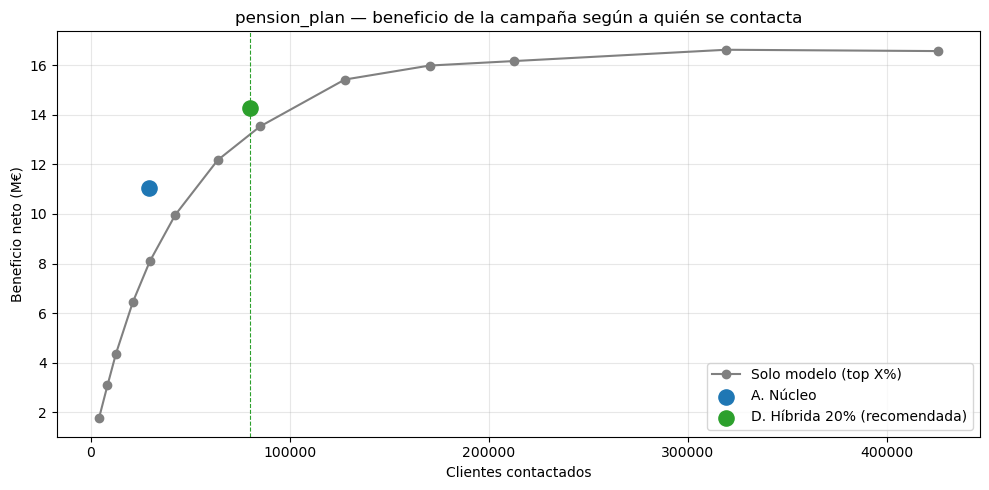

In [15]:
# Curva de beneficio por corte del modelo, con las estrategias A y D marcadas.
# Muestra que la segmentación consigue casi el mismo beneficio con muchos menos contactos.
b = p["beneficio"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(b["clientes"], b["beneficio"] / 1e6, marker="o", color="grey", label="Solo modelo (top X%)")
ax.scatter(hib_a["contactos"], hib_a["beneficio"] / 1e6, s=120, color="tab:blue", zorder=5, label="A. Núcleo")
ax.scatter(hib_d["contactos"], hib_d["beneficio"] / 1e6, s=120, color="tab:green", zorder=5, label="D. Híbrida 20% (recomendada)")
ax.axvline(hib_d["contactos"], color="tab:green", ls="--", lw=0.8)
ax.set_xlabel("Clientes contactados")
ax.set_ylabel("Beneficio neto (M€)")
ax.set_title("pension_plan — beneficio de la campaña según a quién se contacta")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

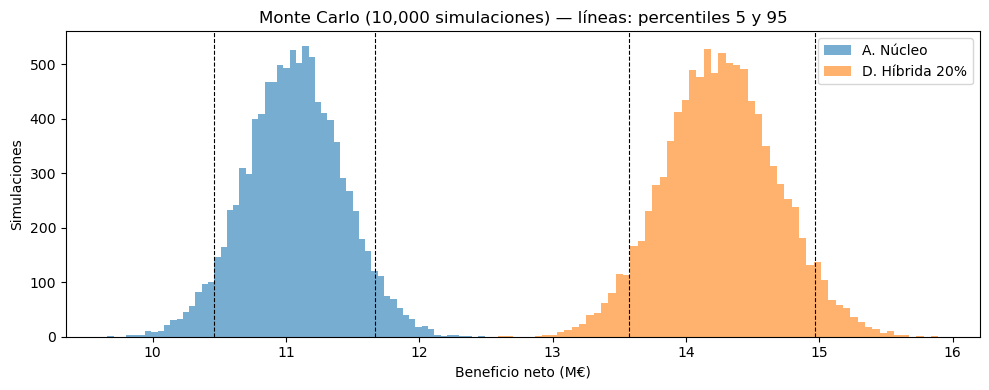

In [16]:
# Distribución del beneficio simulado: el intervalo del 90% es lo que se comunica a negocio.
fig, ax = plt.subplots(figsize=(10, 4))
for etiqueta, res in RESULTADOS_MC.items():
    ax.hist(res / 1e6, bins=60, alpha=0.6, label=etiqueta)
    p5, p95 = np.percentile(res, [5, 95]) / 1e6
    ax.axvline(p5, ls="--", lw=0.8, color="black")
    ax.axvline(p95, ls="--", lw=0.8, color="black")
ax.set_xlabel("Beneficio neto (M€)")
ax.set_ylabel("Simulaciones")
ax.set_title(f"Monte Carlo ({N_SIMULACIONES:,} simulaciones) — líneas: percentiles 5 y 95")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Tablas ligeras para el simulador (Streamlit). Toda la lógica pesada queda en este notebook;
# la app solo lee estos ficheros y los combina.
import os
ruta_app = "../data/app/"
os.makedirs(ruta_app, exist_ok=True)

for nombre, q in PRODUCTOS.items():
    q["curva"].to_csv(ruta_app + f"curva_{nombre}.csv", index=False)
    pd.Series(q["margenes"], name="net_margin").to_csv(ruta_app + f"margenes_{nombre}.csv", index=False)

    por_grupo, _ = cruce_grupos(q, 30)
    por_grupo.reset_index().to_csv(ruta_app + f"conversion_grupo_{nombre}.csv", index=False)

    sc_q = q["scoring"].merge(grupos, on="pk_cid", how="left")
    sc_q["nombre_grupo"] = sc_q["nombre_grupo"].fillna("Sin grupo")
    sc_q[["pk_cid", q["col_prob"], "nombre_grupo"]].to_csv(ruta_app + f"scoring_grupo_{nombre}.csv", index=False)

    q["validacion"].merge(grupos_abril, on="pk_cid", how="left").to_csv(ruta_app + f"validacion_grupo_{nombre}.csv", index=False)

hib.to_csv(ruta_app + "estrategias_hibridas.csv", index=False)
print(sorted(os.listdir(ruta_app)))

['conversion_grupo_em_acount.csv', 'conversion_grupo_pension_plan.csv', 'curva_em_acount.csv', 'curva_pension_plan.csv', 'estrategias_hibridas.csv', 'margenes_em_acount.csv', 'margenes_pension_plan.csv', 'scoring_grupo_em_acount.csv', 'scoring_grupo_pension_plan.csv', 'validacion_grupo_em_acount.csv', 'validacion_grupo_pension_plan.csv']


¿Qué producto? pension_plan. Una venta deja 5.976 €; em_acount, 70 €. Es el 79% del margen de la empresa.

¿A cuántos? 80.282 clientes, el 19% de los elegibles.

¿Qué segmentos? Clientes de nómina y Particulares con tarjeta completos (convierten al 15% y al 1,8%). De Particulares básicos y Universitarios recién llegados, solo el top 20% del modelo. Universitarios inactivos y Sin producto fuera (61% de la base, 0,1% de conversión).

¿Cuánto dinero? 14,3 M€ en el mes, entre 13,6 y 15,0 con un 90% de probabilidad. Sin escenario de pérdida. Robusto a cualquier canal hasta 60 € por contacto.

Y lo que aporta cada tarea: el modelo solo (top 30%) necesita 127.000 contactos para lo mismo que la híbrida hace con 80.000.